In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Windows 기본 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

#파일을 DataFrame으로 생성하고 객체 할당 
train_df=pd.read_csv(r'C:\Users\user\ESAA_YB\미니프로젝트1\movies_train.csv')


In [3]:
#1번 [전처리 코드]

# 1-1. 수요일 / 목요일 개봉작 필터링
train_df["release_time"] = pd.to_datetime(train_df["release_time"])
train_df["release_dayofweek"] = train_df["release_time"].dt.day_name()
train_df["release_month"] = train_df["release_time"].dt.month

df_wed_thu = train_df[
    train_df["release_dayofweek"].isin(["Wednesday", "Thursday"])
].copy()

# 1-2. 이미지 수치 기준 제작 규모(소/중/대) 구간화
# 소: ~80명 / 중: 81~250명 / 대: 251명~
bins = [-1, 80, 250, np.inf]
labels = ["소(~80명)", "중(81~250명)", "대(251명~)"]
df_wed_thu["scale_group"] = pd.cut(
    df_wed_thu["num_staff"], bins=bins, labels=labels
)

# 1-3. 성수기(1, 7, 8, 12월) 여부 파생 변수
peak_months = [1, 7, 8, 12]
df_wed_thu["is_peak_season"] = df_wed_thu["release_month"].isin(peak_months)

# 수요일 / 목요일 각각의 DataFrame 추출
wed_df = df_wed_thu[df_wed_thu["release_dayofweek"] == "Wednesday"]
thu_df = df_wed_thu[df_wed_thu["release_dayofweek"] == "Thursday"]

In [5]:
#1번 [통계검정코드]

from scipy import stats

# 2-1. 전체 관객 수 및 스태프 수 중앙값
wed_aud_median = wed_df["box_off_num"].median()
thu_aud_median = thu_df["box_off_num"].median()
ratio_aud = wed_aud_median / thu_aud_median

wed_staff_median = wed_df["num_staff"].median()
thu_staff_median = thu_df["num_staff"].median()

# 2-2. Mann-Whitney U 검정 수행 (전체 관객 수 차이)
u_stat, p_val = stats.mannwhitneyu(
    wed_df["box_off_num"], thu_df["box_off_num"], alternative="two-sided"
)

# 2-3. 제작 규모(소/중/대)별 요일 관객수 중앙값 및 표본 수 집계
scale_summary = (
    df_wed_thu.groupby(["scale_group", "release_dayofweek"], observed=False)[
        "box_off_num"
    ]
    .agg(["median", "count"])
    .unstack()
)

print(f"=== [1. 전체 수요일 vs 목요일 요약] ===")
print(
    f"• 관객 수 중앙값 : 수요일 {wed_aud_median:,.0f}명 vs 목요일"
    f" {thu_aud_median:,.0f}명 ({ratio_aud:.1f}배)"
)
print(
    f"• 스태프 수 중앙값: 수요일 {wed_staff_median:.1f}명 vs 목요일"
    f" {thu_staff_median:.1f}명"
)
print(f"• Mann-Whitney U test p-value: {p_val:.4e}\n")

print(f"=== [2. 제작 규모(소/중/대) 통제 후 요일별 성적] ===")
for scale in labels:
    w_med = scale_summary.loc[scale, ("median", "Wednesday")]
    t_med = scale_summary.loc[scale, ("median", "Thursday")]
    w_cnt = scale_summary.loc[scale, ("count", "Wednesday")]
    t_cnt = scale_summary.loc[scale, ("count", "Thursday")]
    ratio = w_med / t_med if t_med > 0 else 0
    print(
        f"[{scale}] 수요일: {w_med:,.0f}명({w_cnt}편) | 목요일:"
        f" {t_med:,.0f}명({t_cnt}편) -> {ratio:.1f}배"
    )

=== [1. 전체 수요일 vs 목요일 요약] ===
• 관객 수 중앙값 : 수요일 1,025,243명 vs 목요일 5,922명 (173.1배)
• 스태프 수 중앙값: 수요일 331.0명 vs 목요일 61.0명
• Mann-Whitney U test p-value: 4.4815e-21

=== [2. 제작 규모(소/중/대) 통제 후 요일별 성적] ===
[소(~80명)] 수요일: 2,146명(23편) | 목요일: 1,850명(268편) -> 1.2배
[중(81~250명)] 수요일: 867,386명(13편) | 목요일: 12,943명(122편) -> 67.0배
[대(251명~)] 수요일: 1,646,142명(71편) | 목요일: 849,407명(94편) -> 1.9배


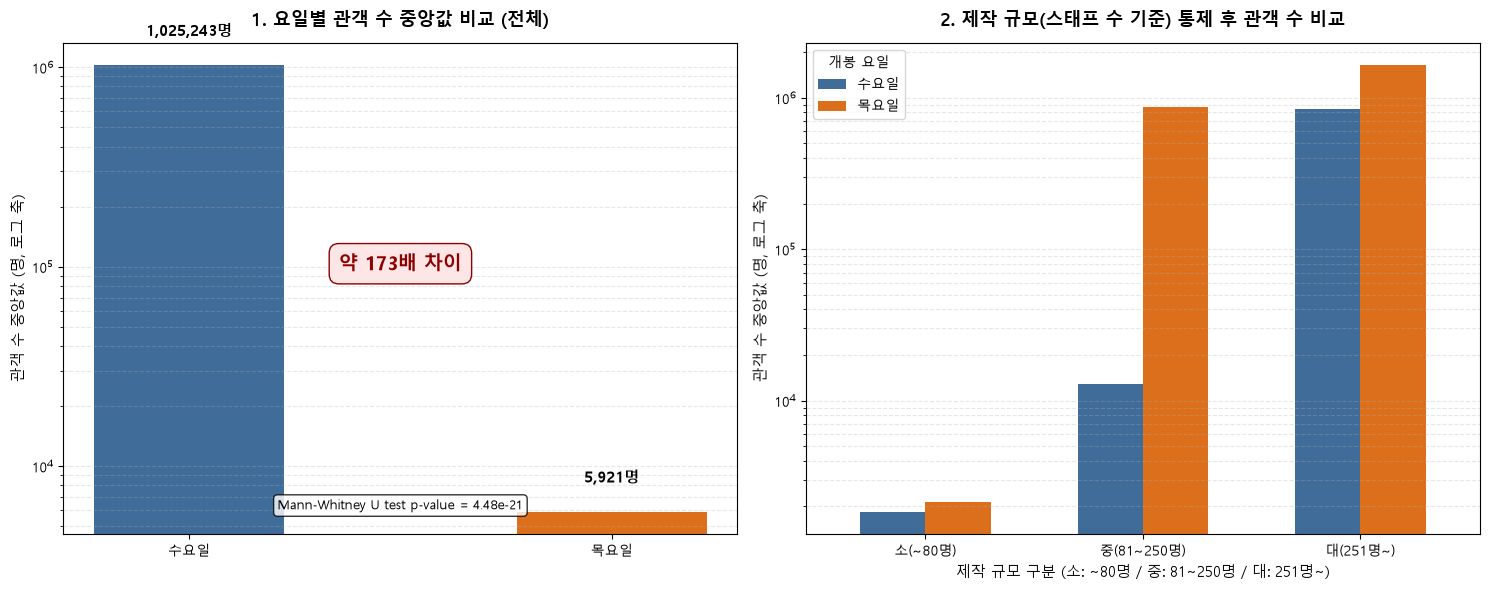

In [7]:
#1번 [시각화코드]

# 한글 폰트 설정 (Windows 기준)
plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

# 2단 서브플롯 생성 (1행 2열)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = ["#2b5c8f", "#d95f02"]  # 수요일(파랑), 목요일(주황)

# =========================================================
# [왼쪽 그래프] 1. 전체 요일별 관객 수 중앙값 (수 vs 목)
# =========================================================
days = ["수요일", "목요일"]
medians = [wed_aud_median, thu_aud_median]

bars = ax1.bar(days, medians, color=colors, width=0.45, alpha=0.9)
ax1.set_yscale("log")  # 축만 로그 스케일로 설정 (실제 관객수 숫자로 표시)

# 막대 상단에 실제 관객 수 수치 명시 (피드백 ① 반영)
for bar, median in zip(bars, medians):
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        median * 1.35,
        f"{int(median):,}명",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# 중앙에 "173배" 차이 강조 박스
ax1.text(
    0.5,
    0.55,
    f"약 {ratio_aud:.0f}배 차이",
    transform=ax1.transAxes,
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color="darkred",
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="#ffe6e6", edgecolor="darkred"
    ),
)

# p-value 정보 표기 (피드백 ⑤ 반영)
ax1.text(
    0.5,
    0.05,
    f"Mann-Whitney U test p-value = {p_val:.2e}",
    transform=ax1.transAxes,
    ha="center",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

ax1.set_title(
    "1. 요일별 관객 수 중앙값 비교 (전체)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax1.set_ylabel("관객 수 중앙값 (명, 로그 축)", fontsize=11)
ax1.grid(True, which="both", axis="y", linestyle="--", alpha=0.3)


# =========================================================
# [오른쪽 그래프] 2. 제작 규모(소·중·대) 통제 후 관객 수 비교
# =========================================================
# 규모(scale_group) 및 요일(release_dayofweek)별 관객수 중앙값 집계
scale_summary = (
    df_wed_thu.groupby(["scale_group", "release_dayofweek"], observed=False)[
        "box_off_num"
    ]
    .median()
    .unstack()
)

# 그룹 막대 그래프 시각화
scale_summary.plot(
    kind="bar", ax=ax2, color=colors, width=0.6, rot=0, alpha=0.9
)
ax2.set_yscale("log")

ax2.set_title(
    "2. 제작 규모(스태프 수 기준) 통제 후 관객 수 비교",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax2.set_xlabel("제작 규모 구분 (소: ~80명 / 중: 81~250명 / 대: 251명~)", fontsize=11)
ax2.set_ylabel("관객 수 중앙값 (명, 로그 축)", fontsize=11)
ax2.legend(["수요일", "목요일"], title="개봉 요일")
ax2.grid(True, which="both", axis="y", linestyle="--", alpha=0.3)

# 규모별 배수 표기 (피드백 ③ 반영: 173배가 1.2배 ~ 1.9배로 줄어드는 효과 강조)
# 소/대 규모 기준 배수 계산 및 텍스트 추가
for i, scale in enumerate(["소", "중", "대"]):
    try:
        w_val = scale_summary.loc[scale, "Wednesday"]
        t_val = scale_summary.loc[scale, "Thursday"]
        mult = w_val / t_val

        ax2.text(
            i,
            max(w_val, t_val) * 1.5,
            f"{mult:.1f}배",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="#8c1111",
        )
    except KeyError:
        pass

plt.tight_layout()
plt.show()

In [8]:
#5번 [전처리 코드]

# 1) 띄어쓰기 제거 및 '(주)' 텍스트 정리
def clean_distributor(x):
    x = str(x).strip()
    x = x.replace('(주)', '').replace('주식회사', '').strip()
    # 자주 틀리는 공통 이름 일치시키기
    if '쇼박스' in x:
        return '쇼박스'
    elif 'CJ' in x or '씨제이' in x:
        return 'CJ엔터테인먼트'
    elif '롯데' in x:
        return '롯데엔터테인먼트'
    elif 'NEW' in x or '뉴' in x:
        return 'NEW'
    return x

train_df['distributor_clean'] = train_df['distributor'].apply(clean_distributor)


# 1-1. 스태프 수 기준 제작 규모(소/중/대) 구간화
# 소: ~80명 / 중: 81~250명 / 대: 251명~
bins = [-1, 80, 250, np.inf]
labels = ["소규모 (~80명)", "중규모 (81~250명)", "대규모 (251명~)"]
train_df["scale_group"] = pd.cut(
    train_df["num_staff"], bins=bins, labels=labels
)

# 1-2. 관객 수 로그 변환
train_df["log_box_off_num"] = np.log1p(train_df["box_off_num"])


In [9]:
#5번 [통계검정 코드]

import statsmodels.api as sm
from statsmodels.formula.api import ols

# 2-1. 제작 규모(소/중/대)의 관객 수 설명력(R²) 측정
model_scale = ols("log_box_off_num ~ C(scale_group)", data=train_df).fit()
r2_scale = model_scale.rsquared

# 2-2. 제작 규모별 관객 수 중앙값 및 편수 집계
scale_stats = (
    train_df.groupby("scale_group", observed=False)["box_off_num"]
    .agg(편수="count", 관객수_중앙값="median")
    .reset_index()
)

print(f"=== [제작 규모(스태프 수) 기준 분석 요약] ===")
print(f"• 제작 규모(소/중/대)의 관객 수 설명력 (R²) : {r2_scale:.3f}\n")
print(scale_stats.to_string(index=False))

=== [제작 규모(스태프 수) 기준 분석 요약] ===
• 제작 규모(소/중/대)의 관객 수 설명력 (R²) : 0.562

  scale_group  편수   관객수_중앙값
   소규모 (~80명) 297    1806.0
중규모 (81~250명) 138   17752.5
  대규모 (251명~) 165 1169546.0


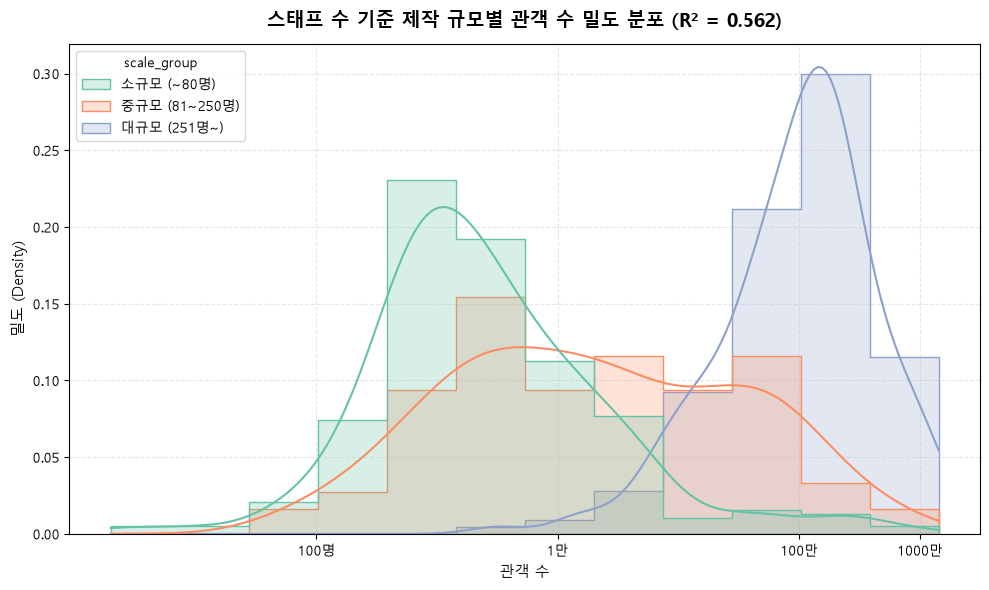

In [10]:
#5번 [시각화 코드]


# 한글 폰트 설정
plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(10, 6))

# x축 로그 눈금 설정 (실제 관객 수 단위)
ticks = [100, 10000, 1000000, 10000000]
log_ticks = np.log1p(ticks)
tick_labels = ["100명", "1만", "100만", "1000만"]

# 제작 규모별 밀도 분포 그래프
ax = sns.histplot(
    data=train_df,
    x="log_box_off_num",
    hue="scale_group",
    kde=True,
    element="step",
    stat="density",  # 그룹별 밀도(Density) 비교
    common_norm=False,  # 각 그룹의 합을 100%로 설정
    palette="Set2",
)

plt.title(
    f"스태프 수 기준 제작 규모별 관객 수 밀도 분포 (R² = {r2_scale:.3f})",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
plt.xlabel("관객 수", fontsize=11)
plt.ylabel("밀도 (Density)", fontsize=11)

# x축 실제 관객 수 명시
ax.set_xticks(log_ticks)
ax.set_xticklabels(tick_labels)

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
#7번 [전처리 코드]

#결측값=0으로 채우기
train_df['dir_prev_bfnum'] = train_df['dir_prev_bfnum'].fillna(0)

#관객 수 로그 변환 (np.log1p 사용: 0이 들어와도 안전하게 변환)
train_df['log_box_off_num'] = np.log1p(train_df['box_off_num'])

#감독별 이전 영화 관객 수의 로그 변환 
train_df['log_dir_prev_bfnum'] = np.log1p(train_df['dir_prev_bfnum'])

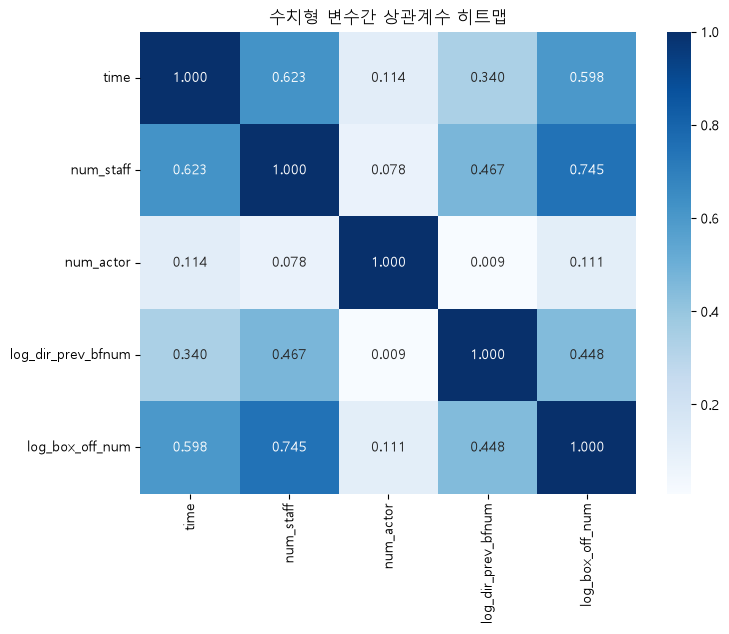

In [12]:
#7번 [시각화 코드]

# 상관계수 히트맵
plt.figure(figsize=(8, 6))
num_cols = ['time', 'num_staff', 'num_actor', 'log_dir_prev_bfnum', 'log_box_off_num']
sns.heatmap(train_df[num_cols].corr(), annot=True, cmap='Blues', fmt='.3f')
plt.title('수치형 변수간 상관계수 히트맵')
plt.show()